# Disease Prediction from Medical Data

**Educational / research project:** This notebook predicts a disease-positive or disease-negative class from a publicly available structured medical dataset. It is **not a medical diagnosis system** and must not be used to make medical decisions.

We use the **UCI Heart Disease (Cleveland) dataset**. The original target `num` has values 0–4; for this binary classification project, `0` is treated as disease-negative and values `1–4` as disease-positive.

## 1. Introduction

Machine learning can learn patterns from structured patient attributes and use those patterns to classify records into predefined classes. In this project, medical attributes such as age, blood pressure, cholesterol, exercise-related measurements, and other recorded variables are used as model inputs.

The goal is to demonstrate a complete supervised classification workflow: data loading, cleaning, EDA, preprocessing, model training, evaluation, cross-validation, tuning, feature importance, sample prediction, and model saving.

**Important limitation:** a machine-learning prediction is not the same as a clinical diagnosis. Dataset quality, population differences, measurement errors, class imbalance, and model assumptions can affect predictions.

## 2. Problem Statement

Develop a machine learning classification system that analyzes structured medical data and predicts whether a patient belongs to a disease-positive or disease-negative class.

- **Input:** patient medical attributes
- **Output:** predicted class
- **Problem type:** supervised binary classification
- **Target:** `num` from the UCI Heart Disease dataset, converted to binary

## 3. Objective

1. Inspect and understand the dataset.
2. Clean and preprocess the data without data leakage.
3. Explore the data using understandable visualizations.
4. Train Logistic Regression, SVM, Random Forest, and XGBoost.
5. Compare accuracy, precision, recall, F1-score, and ROC-AUC.
6. Use cross-validation and optional hyperparameter tuning.
7. Inspect feature importance for tree-based models.
8. Build a sample prediction system.
9. Save the complete preprocessing + model pipeline.

## 4. Dataset Description

This notebook uses the **UCI Heart Disease dataset**, specifically the Cleveland data distributed through the UCI Machine Learning Repository.

The commonly used Cleveland version contains 303 records and 13 predictor variables plus the target `num`.

Main variables include:

- `age`: age in years
- `sex`: sex code
- `cp`: chest-pain type code
- `trestbps`: resting blood pressure
- `chol`: serum cholesterol
- `fbs`: fasting blood sugar indicator
- `restecg`: resting electrocardiographic result
- `thalach`: maximum heart rate achieved
- `exang`: exercise-induced angina indicator
- `oldpeak`: ST depression
- `slope`: slope of the peak exercise ST segment
- `ca`: number of major vessels
- `thal`: thalassemia-related code
- `num`: original disease/diagnosis target

The code below **inspects the downloaded data before relying on columns**, rather than silently assuming a schema.

## 5. Import Libraries

In [1]:
# Core libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# XGBoost
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip -q install xgboost
    from xgboost import XGBClassifier

# Save/load trained pipelines
import joblib

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")

Libraries imported successfully.


## 6. Load Dataset

### Google Colab option

The simplest approach is to download the UCI Heart Disease data programmatically with `ucimlrepo`.

If you instead have a CSV file, upload it with the Colab file picker and replace the loading section with:

```python
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded)))
```

Do not fabricate patient records. Use the public dataset or another legitimate dataset.

In [2]:
# Install the small helper package used to download the UCI dataset.
!pip -q install ucimlrepo

from ucimlrepo import fetch_ucirepo

# Fetch UCI Heart Disease dataset (dataset ID 45)
heart_disease = fetch_ucirepo(id=45)

# Features and target supplied by the repository package
X_raw = heart_disease.data.features.copy()
y_raw = heart_disease.data.targets.copy()

# Combine them so the complete dataset can be inspected.
df = pd.concat([X_raw, y_raw], axis=1)

print("Dataset loaded.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
display(df.head())

Dataset loaded.
Shape: (303, 14)

Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 7. Data Understanding

In [3]:
print("First 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nShape:", df.shape)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().to_frame("missing_values"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0



Last 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
298,45,1,1,110,264,0,0,132,0,1.2,2,0.0,7.0,1
299,68,1,4,144,193,1,0,141,0,3.4,2,2.0,7.0,2
300,57,1,4,130,131,0,0,115,1,1.2,2,1.0,7.0,3
301,57,0,2,130,236,0,2,174,0,0.0,2,1.0,3.0,1
302,38,1,3,138,175,0,0,173,0,0.0,1,NaN,3.0,0



Shape: (303, 14)

Data types:


,dtype
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64



Missing values:


,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Duplicate rows: 0

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


### Standardize the target column

The UCI package may return the target as `num`. We verify it rather than inventing a target name. For binary classification, the original target is mapped as:

- `0` → 0 (disease-negative)
- `1, 2, 3, 4` → 1 (disease-positive)

In [4]:
# Verify that the expected target exists.
if "num" not in df.columns:
    raise ValueError(
        f"Expected UCI target column 'num' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

# Convert common missing-value markers to NaN.
df = df.replace(["?", "NA", "N/A", ""], np.nan)

# Convert columns to numeric where possible.
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Convert the original 0-4 target to binary.
df["target"] = (df["num"] > 0).astype(int)
df.drop(columns=["num"], inplace=True)

print("Final columns:")
print(df.columns.tolist())

print("\nBinary target distribution:")
display(df["target"].value_counts().sort_index().to_frame("count"))

Final columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Binary target distribution:


,count
target,
0,164
1,139


## 8. Data Cleaning

Missing values are handled inside preprocessing pipelines using the **median for numerical variables** and the **most frequent value for categorical variables**. This is important because imputation learns values from the data.

Duplicates are removed before the train-test split because they represent repeated records rather than useful independent observations.

In [5]:
# Remove exact duplicate rows.
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} duplicate row(s).")
print("New shape:", df.shape)

print("\nMissing values after cleaning markers:")
display(df.isna().sum().to_frame("missing_values"))

Removed 0 duplicate row(s).
New shape: (303, 14)

Missing values after cleaning markers:


,missing_values
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


## 9. Exploratory Data Analysis (EDA)

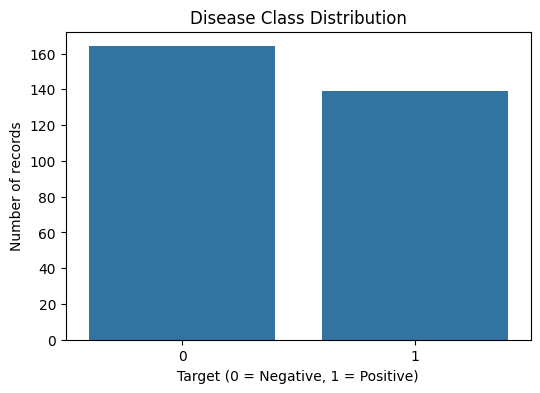

Interpretation: This graph shows how many records belong to each classification class.


In [6]:
# Target/class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="target")
plt.title("Disease Class Distribution")
plt.xlabel("Target (0 = Negative, 1 = Positive)")
plt.ylabel("Number of records")
plt.show()

print("Interpretation: This graph shows how many records belong to each classification class.")

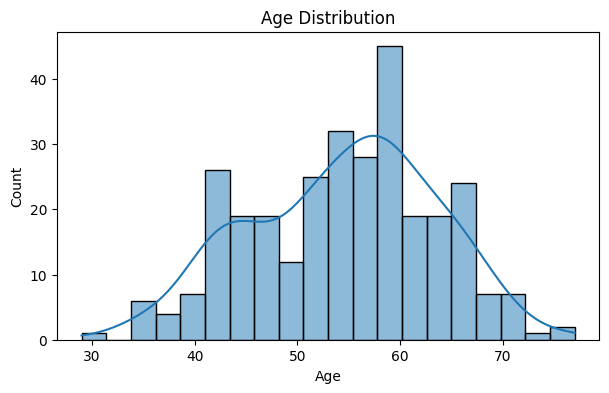

Interpretation: The graph shows how ages are distributed in the dataset.


In [7]:
# Age distribution
plt.figure(figsize=(7, 4))
sns.histplot(data=df, x="age", bins=20, kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

print("Interpretation: The graph shows how ages are distributed in the dataset.")

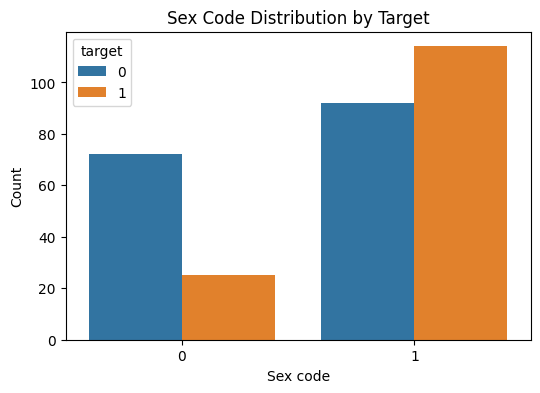

Interpretation: This compares the recorded sex codes across the two target classes.


In [8]:
# Gender/sex code distribution, if available
if "sex" in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x="sex", hue="target")
    plt.title("Sex Code Distribution by Target")
    plt.xlabel("Sex code")
    plt.ylabel("Count")
    plt.show()
    print("Interpretation: This compares the recorded sex codes across the two target classes.")
else:
    print("'sex' is not present in this dataset.")

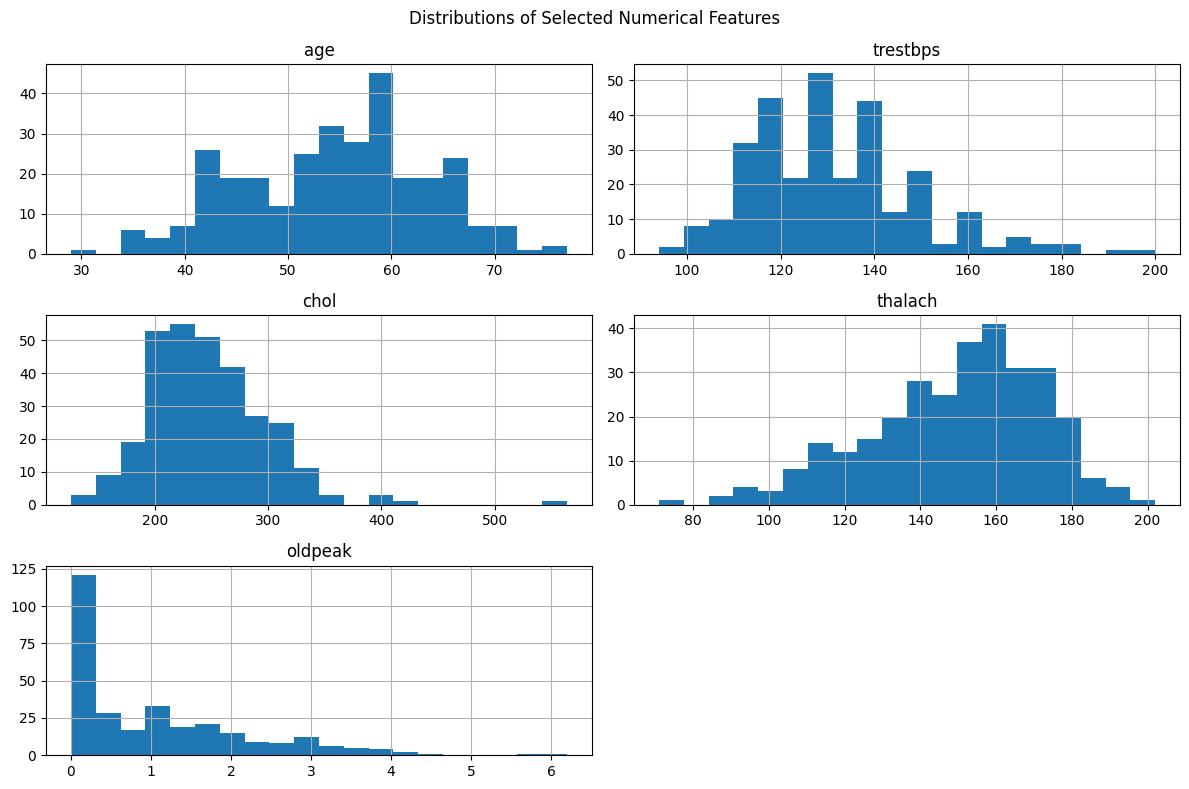

Interpretation: These plots show the spread and approximate shape of selected numerical variables.


In [9]:
# Histograms for important numerical features
numeric_for_eda = [c for c in ["age", "trestbps", "chol", "thalach", "oldpeak"] if c in df.columns]

df[numeric_for_eda].hist(figsize=(12, 8), bins=20)
plt.suptitle("Distributions of Selected Numerical Features")
plt.tight_layout()
plt.show()

print("Interpretation: These plots show the spread and approximate shape of selected numerical variables.")

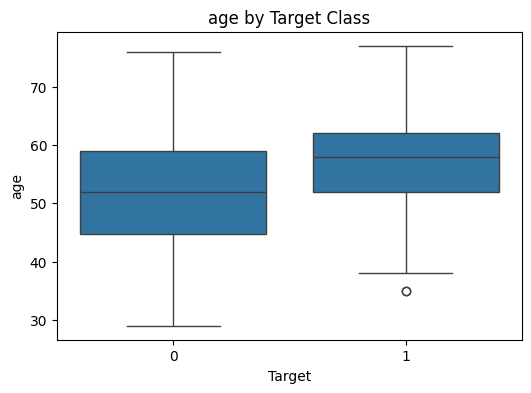

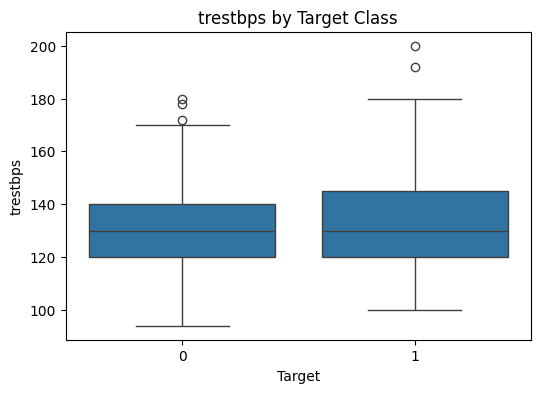

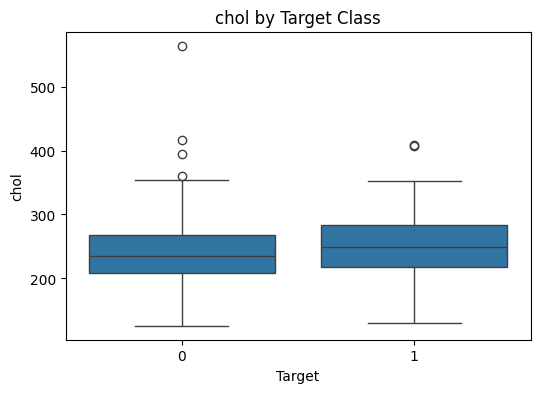

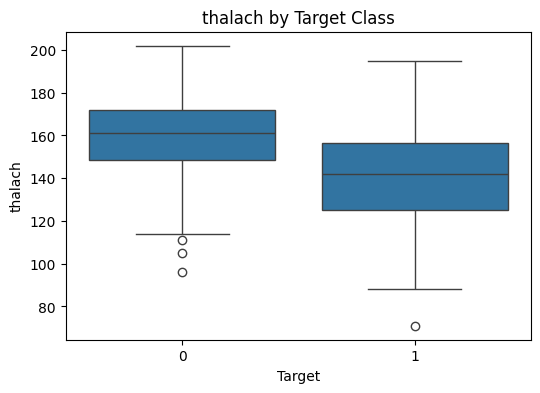

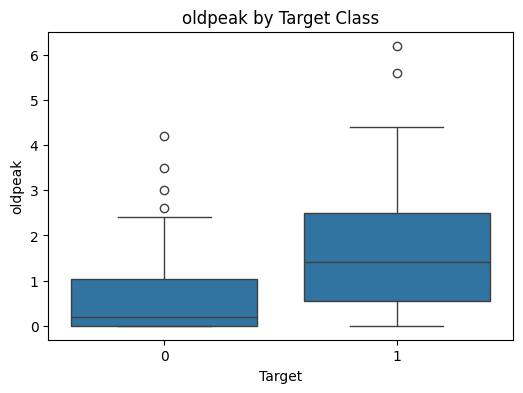

Interpretation: Boxplots help compare the distributions and identify possible outliers.


In [10]:
# Boxplots by target
for col in [c for c in ["age", "trestbps", "chol", "thalach", "oldpeak"] if c in df.columns]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="target", y=col)
    plt.title(f"{col} by Target Class")
    plt.xlabel("Target")
    plt.ylabel(col)
    plt.show()

print("Interpretation: Boxplots help compare the distributions and identify possible outliers.")

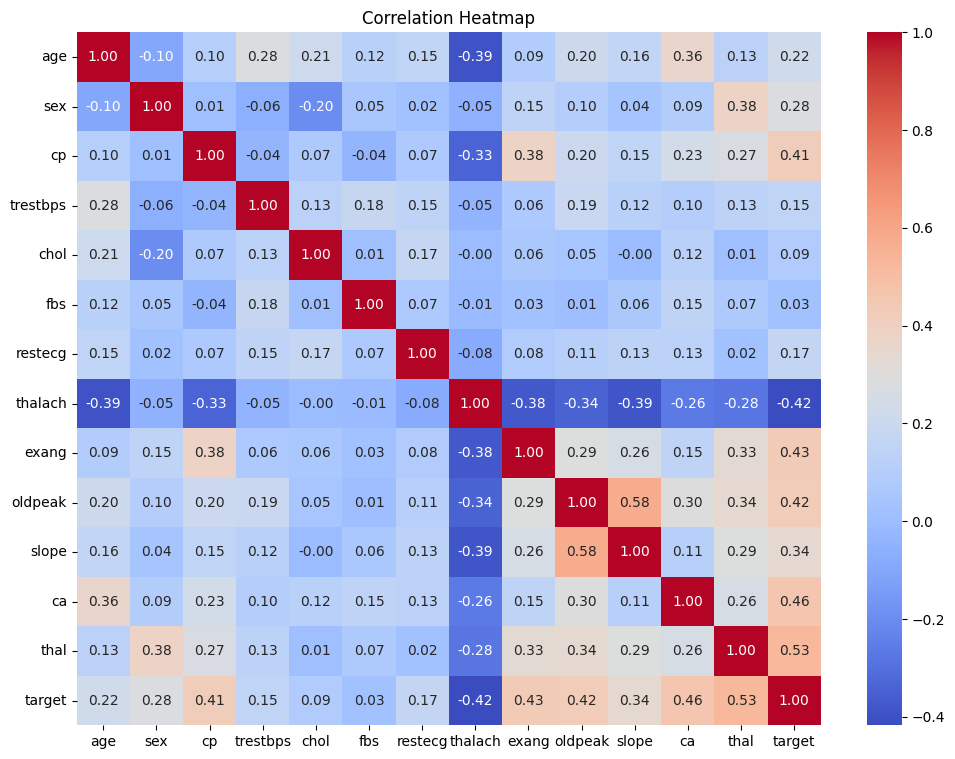

Interpretation: Correlation describes linear association between numeric variables. It does not prove that one variable causes disease.


In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print(
    "Interpretation: Correlation describes linear association between numeric variables. "
    "It does not prove that one variable causes disease."
)

## 10. Feature-Target Separation

In [12]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nFeature names:")
print(X.columns.tolist())

print("\nTarget distribution:")
display(y.value_counts().sort_index().to_frame("count"))

X shape: (303, 13)
y shape: (303,)

Feature names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Target distribution:


,count
target,
0,164
1,139


## 11. Train-Test Split

An 80/20 stratified split is used. Stratification helps preserve the approximate class proportions in both sets. The test set remains held out for final evaluation.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("proportion"))

Training shape: (242, 13)
Testing shape: (61, 13)

Training target distribution:


,proportion
target,
0,0.541322
1,0.458678



Testing target distribution:


,proportion
target,
0,0.540984
1,0.459016


## 12. Preprocessing and Feature Scaling

The UCI variables are a mixture of numerical measurements and coded categorical variables. We explicitly define the categorical codes and numerical measurements used by the dataset.

- Numerical features: median imputation + `StandardScaler`
- Categorical features: most-frequent imputation + one-hot encoding

Scaling is useful for Logistic Regression and SVM because their optimization/distance calculations can be affected by feature magnitude.

Tree-based models generally do not require feature scaling, but using a consistent preprocessing pipeline keeps the workflow reproducible.

In [14]:
categorical_candidates = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
categorical_features = [c for c in categorical_candidates if c in X.columns]
numerical_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("Numerical features:", numerical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessor created.")

Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Preprocessor created.


## 13. Model Definitions

Four required classification models are trained:

1. Logistic Regression
2. Support Vector Machine (SVM)
3. Random Forest
4. XGBoost

The initial parameters are intentionally reasonable and beginner-friendly. They are not claimed to be medically optimal.

In [15]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
}

pipelines = {
    name: Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

print("Created", len(pipelines), "model pipelines.")

Created 4 model pipelines.


## 14. Train Models and Evaluate

For every model we calculate accuracy, precision, recall, F1-score, and ROC-AUC where a score/probability is available.

In [16]:
results = []
fitted_models = {}
prediction_data = {}

for name, pipe in pipelines.items():
    print(f"\n===== {name} =====")

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    y_pred = pipe.predict(X_test)

    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    metrics_row = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    }

    results.append(metrics_row)
    prediction_data[name] = {"y_pred": y_pred, "y_score": y_score}

    print(classification_report(
        y_test, y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

results_df = pd.DataFrame(results).set_index("Model").sort_values(
    by="F1-Score", ascending=False
)

display(results_df.round(4))


===== Logistic Regression =====
              precision    recall  f1-score   support

    Negative       0.93      0.85      0.89        33
    Positive       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


===== SVM =====
              precision    recall  f1-score   support

    Negative       0.93      0.85      0.89        33
    Positive       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61


===== Random Forest =====
              precision    recall  f1-score   support

    Negative       0.93      0.82      0.87        33
    Positive       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
XGBoost,0.9016,0.8438,0.9643,0.9000,0.9502
Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
SVM,0.8852,0.8387,0.9286,0.8814,0.9643
Random Forest,0.8689,0.8125,0.9286,0.8667,0.9443


## 15. Confusion Matrices

- **True Positive (TP):** positive record correctly predicted positive.
- **True Negative (TN):** negative record correctly predicted negative.
- **False Positive (FP):** negative record predicted positive.
- **False Negative (FN):** positive record predicted negative.

In screening-style applications, false negatives can be important because a positive case may be missed. However, the appropriate error trade-off depends on the intended use and clinical context.

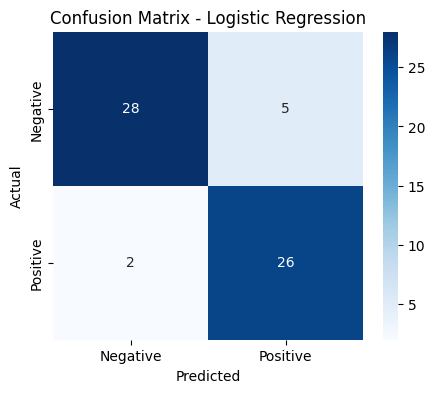

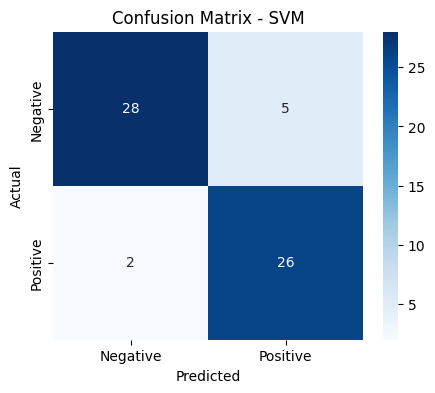

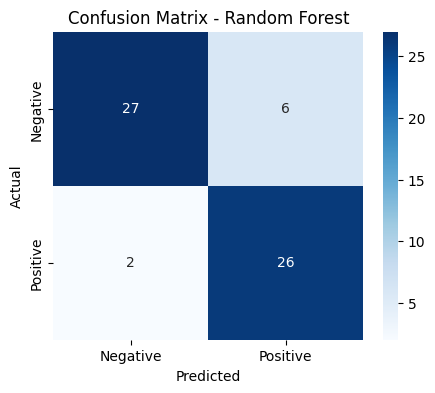

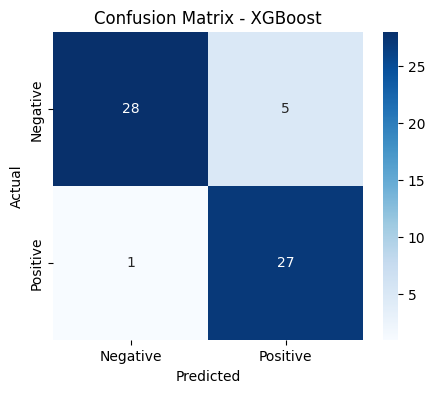

In [17]:
figures = []

for name, data in prediction_data.items():
    cm = confusion_matrix(y_test, data["y_pred"])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 16. ROC Curves

The ROC curve plots:

- **False Positive Rate** on the x-axis
- **True Positive Rate** on the y-axis

AUC summarizes the model's ability to separate the two classes across thresholds.

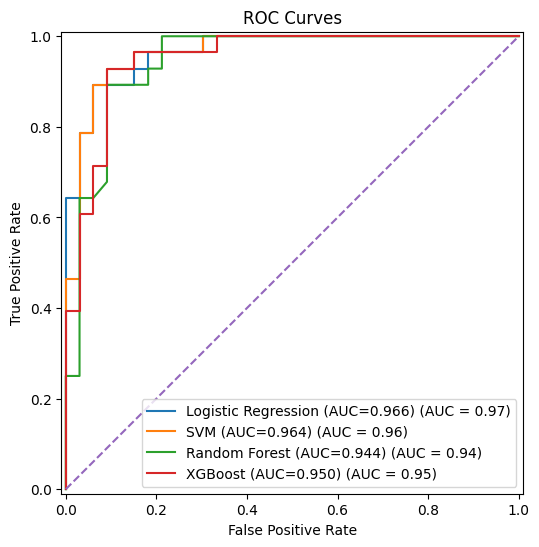

In [18]:
plt.figure(figsize=(8, 6))

for name, data in prediction_data.items():
    RocCurveDisplay.from_predictions(
        y_test,
        data["y_score"],
        name=f"{name} (AUC={roc_auc_score(y_test, data['y_score']):.3f})",
        ax=plt.gca()
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

## 17. Model Comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,XGBoost,0.902,0.844,0.964,0.900,0.950
1,Logistic Regression,0.885,0.839,0.929,0.881,0.966
2,SVM,0.885,0.839,0.929,0.881,0.964
3,Random Forest,0.869,0.812,0.929,0.867,0.944


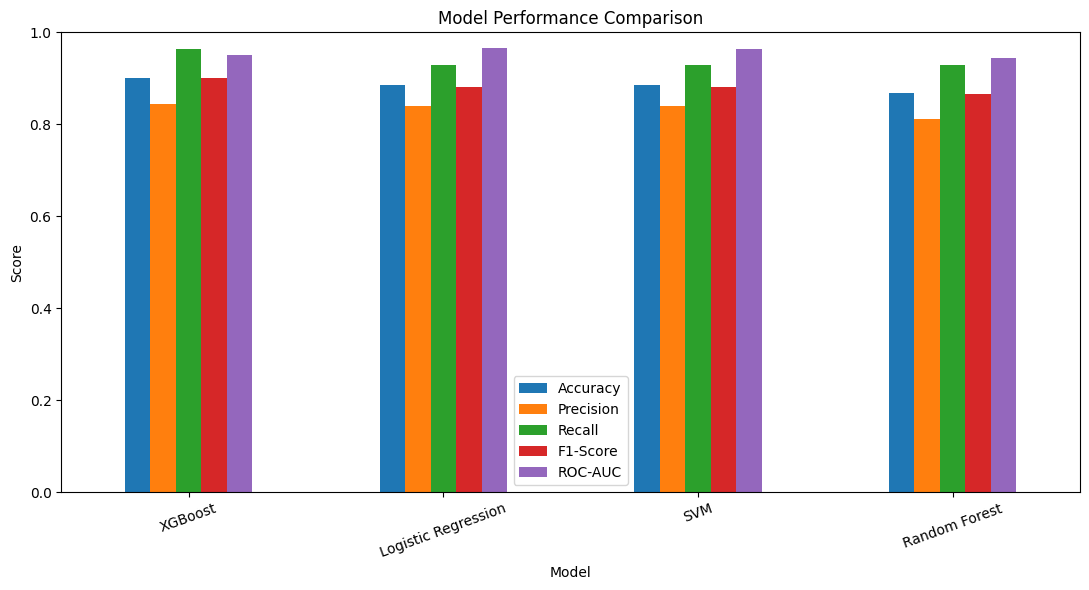

Interpretation: Compare the measured metrics rather than declaring a medically best model. Model selection should depend on the intended use, error trade-offs, validation results, and dataset characteristics.


In [19]:
# Clean comparison table
comparison_df = results_df.reset_index()

display(comparison_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-Score": "{:.3f}",
    "ROC-AUC": "{:.3f}"
}))

# Visual comparison
plot_df = comparison_df.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"
]]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("Model Performance Comparison")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print(
    "Interpretation: Compare the measured metrics rather than declaring a medically "
    "best model. Model selection should depend on the intended use, error trade-offs, "
    "validation results, and dataset characteristics."
)

## 18. Cross-Validation

Five-fold `StratifiedKFold` cross-validation is performed on the training data only. This gives several validation measurements instead of relying on a single split.

The test set is still kept untouched for final evaluation.

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_rows = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_rows.append({
        "Model": name,
        "CV Accuracy Mean": scores["test_accuracy"].mean(),
        "CV Precision Mean": scores["test_precision"].mean(),
        "CV Recall Mean": scores["test_recall"].mean(),
        "CV F1 Mean": scores["test_f1"].mean(),
        "CV ROC-AUC Mean": scores["test_roc_auc"].mean()
    })

cv_results_df = pd.DataFrame(cv_rows).set_index("Model")
display(cv_results_df.round(4))

,CV Accuracy Mean,CV Precision Mean,CV Recall Mean,CV F1 Mean,CV ROC-AUC Mean
Model,,,,,
Logistic Regression,0.8471,0.8768,0.7834,0.8245,0.9025
SVM,0.8139,0.8303,0.7648,0.7893,0.8884
Random Forest,0.8139,0.7967,0.8008,0.7958,0.8936
XGBoost,0.7975,0.7845,0.7743,0.7770,0.8657


## 19. Hyperparameter Tuning

`GridSearchCV` is used on the training data. The test set is not used to choose parameters.

The grids below are intentionally moderate so they remain practical in Google Colab.

In [21]:
param_grids = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["linear", "rbf"],
        "model__gamma": ["scale", "auto"]
    },
    "Random Forest": {
        "model__n_estimators": [200, 400],
        "model__max_depth": [None, 5, 10],
        "model__min_samples_split": [2, 5]
    },
    "XGBoost": {
        "model__n_estimators": [100, 200],
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.03, 0.1],
        "model__subsample": [0.8, 1.0]
    }
}

tuned_models = {}
tuning_rows = []

# ROC-AUC is used as the tuning score here. This is a project choice,
# not a universal clinical rule.
for name, pipe in pipelines.items():
    print(f"Tuning {name}...")

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grids[name],
        scoring="roc_auc",
        cv=cv,
        n_jobs=-1,
        refit=True
    )

    grid.fit(X_train, y_train)
    tuned_models[name] = grid.best_estimator_

    tuning_rows.append({
        "Model": name,
        "Best CV ROC-AUC": grid.best_score_,
        "Best Parameters": grid.best_params_
    })

tuning_df = pd.DataFrame(tuning_rows)
display(tuning_df)

Tuning Logistic Regression...
Tuning SVM...
Tuning Random Forest...
Tuning XGBoost...


,Model,Best CV ROC-AUC,Best Parameters
0,Logistic Regression,0.902493,{'model__C': 1}
1,SVM,0.904743,"{'model__C': 0.1, 'model__gamma': 'scale', 'mo..."
2,Random Forest,0.900372,"{'model__max_depth': None, 'model__min_samples..."
3,XGBoost,0.880765,"{'model__learning_rate': 0.03, 'model__max_dep..."


## 20. Evaluate Tuned Models on the Held-Out Test Set

In [22]:
tuned_results = []

for name, pipe in tuned_models.items():
    y_pred = pipe.predict(X_test)
    y_score = pipe.predict_proba(X_test)[:, 1]

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score)
    })

tuned_results_df = pd.DataFrame(tuned_results).set_index("Model")
display(tuned_results_df.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.8852,0.8387,0.9286,0.8814,0.9665
SVM,0.8361,0.8000,0.8571,0.8276,0.9426
Random Forest,0.8852,0.8387,0.9286,0.8814,0.9470
XGBoost,0.9016,0.8667,0.9286,0.8966,0.9535


## 21. Feature Importance

Random Forest and XGBoost provide feature-importance values after preprocessing.

Because one-hot encoding can expand categorical columns into multiple columns, the code obtains the transformed feature names from the fitted preprocessor.

**Important:** feature importance describes how useful a feature was to the trained model. It does **not** prove that the feature causes disease.

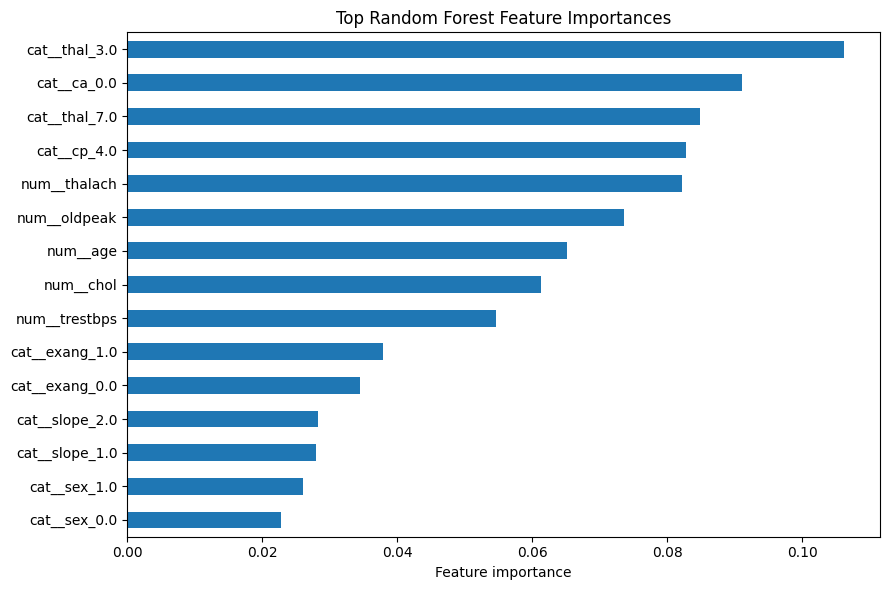

,importance
cat__thal_3.0,0.106220
cat__ca_0.0,0.091074
cat__thal_7.0,0.084817
cat__cp_4.0,0.082860
num__thalach,0.082220
num__oldpeak,0.073628
num__age,0.065185
num__chol,0.061276
num__trestbps,0.054590
cat__exang_1.0,0.037889


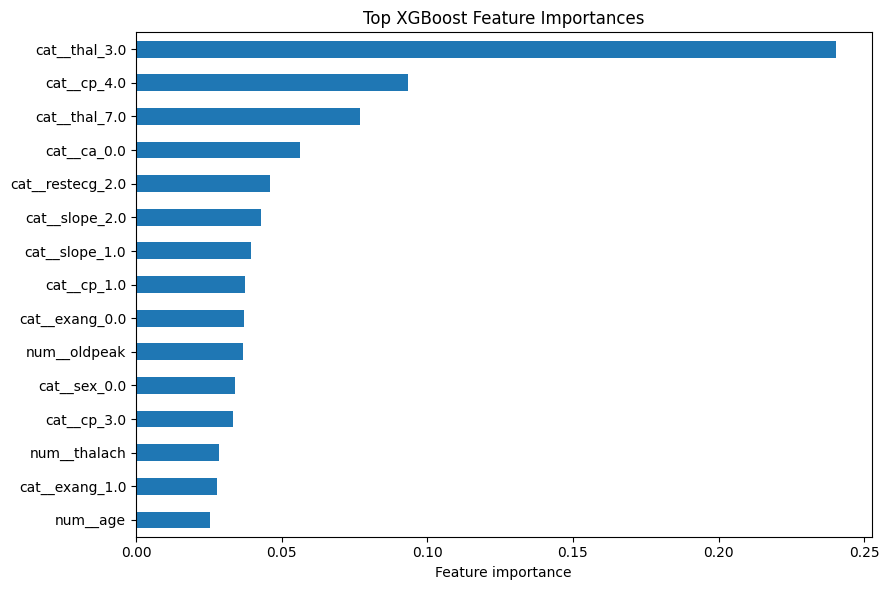

,importance
cat__thal_3.0,0.240451
cat__cp_4.0,0.093502
cat__thal_7.0,0.077042
cat__ca_0.0,0.056466
cat__restecg_2.0,0.046157
cat__slope_2.0,0.042908
cat__slope_1.0,0.039348
cat__cp_1.0,0.037494
cat__exang_0.0,0.037167
num__oldpeak,0.036646


In [23]:
def get_transformed_feature_names(fitted_pipeline):
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    return fitted_preprocessor.get_feature_names_out()

def plot_tree_feature_importance(fitted_pipeline, title):
    model = fitted_pipeline.named_steps["model"]
    feature_names = get_transformed_feature_names(fitted_pipeline)

    importances = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False).head(15)

    plt.figure(figsize=(9, 6))
    importances.sort_values().plot(kind="barh")
    plt.title(title)
    plt.xlabel("Feature importance")
    plt.tight_layout()
    plt.show()

    display(importances.to_frame("importance"))

if "Random Forest" in tuned_models:
    plot_tree_feature_importance(
        tuned_models["Random Forest"],
        "Top Random Forest Feature Importances"
    )

if "XGBoost" in tuned_models:
    plot_tree_feature_importance(
        tuned_models["XGBoost"],
        "Top XGBoost Feature Importances"
    )

## 22. Logistic Regression Coefficients (Optional Interpretation)

For one-hot encoded Logistic Regression, coefficients indicate the direction and strength of association learned by the fitted model. They should not be interpreted as proof of causation.

In [24]:
lr_pipeline = tuned_models["Logistic Regression"]
lr_model = lr_pipeline.named_steps["model"]

lr_feature_names = lr_pipeline.named_steps["preprocessor"].get_feature_names_out()
lr_coefficients = pd.Series(
    lr_model.coef_[0],
    index=lr_feature_names
).sort_values(key=np.abs, ascending=False)

display(lr_coefficients.head(15).to_frame("coefficient"))

,coefficient
cat__ca_0.0,-1.498641
cat__cp_4.0,1.030561
cat__thal_7.0,0.818491
cat__sex_0.0,-0.700836
cat__sex_1.0,0.690353
cat__ca_2.0,0.642171
cat__cp_1.0,-0.619176
cat__slope_2.0,0.603427
cat__cp_3.0,-0.574766
cat__thal_3.0,-0.540243


## 23. Final Model

For a reproducible project, choose the final model using a **predefined validation criterion** rather than selecting a model because it looks good on the held-out test set.

The example below uses the highest mean 5-fold CV ROC-AUC among the tuned candidates. This is a project-specific selection rule, not a statement that ROC-AUC is always the correct metric for medical use.

In [25]:
# Select by the validation criterion defined above.
best_name = tuning_df.loc[
    tuning_df["Best CV ROC-AUC"].idxmax(), "Model"
]

final_model = tuned_models[best_name]

print("Final model selected by highest mean 5-fold CV ROC-AUC:", best_name)

# Final held-out test evaluation
final_pred = final_model.predict(X_test)
final_score = final_model.predict_proba(X_test)[:, 1]

final_metrics = {
    "Accuracy": accuracy_score(y_test, final_pred),
    "Precision": precision_score(y_test, final_pred, zero_division=0),
    "Recall": recall_score(y_test, final_pred, zero_division=0),
    "F1-Score": f1_score(y_test, final_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, final_score)
}

display(pd.DataFrame([final_metrics], index=[best_name]).round(4))

print("\nFinal classification report:")
print(classification_report(
    y_test,
    final_pred,
    target_names=["Negative", "Positive"],
    zero_division=0
))

Final model selected by highest mean 5-fold CV ROC-AUC: SVM


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
SVM,0.8361,0.8,0.8571,0.8276,0.9426



Final classification report:
              precision    recall  f1-score   support

    Negative       0.87      0.82      0.84        33
    Positive       0.80      0.86      0.83        28

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



## 24. Sample Prediction System

The function below accepts a dictionary containing feature values, applies the **same fitted preprocessing pipeline**, and returns the model's class prediction and probability.

The output intentionally says **Model prediction**, not “you have the disease.”

In [26]:
def predict_patient(feature_values, model=final_model):
    """Predict a single record using the fitted end-to-end pipeline."""
    input_df = pd.DataFrame([feature_values])

    # Ensure the input follows the training feature order.
    missing = [c for c in X.columns if c not in input_df.columns]
    extra = [c for c in input_df.columns if c not in X.columns]

    if missing:
        raise ValueError(f"Missing required features: {missing}")
    if extra:
        input_df = input_df.drop(columns=extra)

    input_df = input_df[X.columns]

    prediction = int(model.predict(input_df)[0])
    probability = float(model.predict_proba(input_df)[0, 1])

    label = "Positive" if prediction == 1 else "Negative"

    return {
        "Model prediction": label,
        "Predicted probability of positive class": probability
    }

# Example input based on the dataset schema.
# These are example feature values for demonstrating the interface,
# not a diagnosis or a fabricated training record.
example_patient = {
    "age": 55,
    "sex": 1,
    "cp": 1,
    "trestbps": 130,
    "chol": 250,
    "fbs": 0,
    "restecg": 0,
    "thalach": 150,
    "exang": 0,
    "oldpeak": 1.0,
    "slope": 1,
    "ca": 0,
    "thal": 2
}

prediction_result = predict_patient(example_patient)
print(prediction_result)

print(
    "\nWARNING: This prediction is generated by a machine-learning model "
    "for educational/research purposes and should not be interpreted as a "
    "medical diagnosis. Medical decisions should be made by qualified "
    "healthcare professionals."
)

{'Model prediction': 'Negative', 'Predicted probability of positive class': 0.1641946930066106}



## 25. Save the Complete Model Pipeline

Saving the complete pipeline ensures that new data receives the same preprocessing and model transformation used during training.

In [28]:
# Import required libraries
import os
import joblib

# Create the models folder
MODEL_DIR = "../models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Path where the model will be saved
model_path = os.path.join(
    MODEL_DIR,
    "disease_prediction_model.pkl"
)

# Save the complete preprocessing + model pipeline
joblib.dump(final_model, model_path)

print("Saved model to:", model_path)

# Load the saved model again to verify it
loaded_model = joblib.load(model_path)

print("Loaded model successfully!")
print("Model type:", type(loaded_model))

Saved model to: ../models/disease_prediction_model.pkl
Loaded model successfully!
Model type: <class 'sklearn.pipeline.Pipeline'>


## 26. How to Load the Saved Model Later

In [31]:
import joblib

loaded_model = joblib.load("../models/disease_prediction_model.pkl")

# Use loaded_model.predict(...) or loaded_model.predict_proba(...)
# on a DataFrame with the same input feature columns.

## 27. Limitations

- This is an educational/research project, not a clinical diagnostic system.
- The dataset is relatively small compared with real-world healthcare datasets.
- Results from this dataset may not generalize to other populations or healthcare settings.
- The target is a simplified binary transformation of the original `num` target.
- Dataset coding and missing values can affect results.
- A single dataset cannot establish clinical validity.
- Model probabilities may require calibration before being interpreted as reliable probabilities.
- External validation on independent data is needed before considering real-world deployment.

## 28. Future Improvements

- Use larger and more diverse datasets.
- Perform external validation on an independent dataset.
- Improve handling of class imbalance where required.
- Perform broader hyperparameter optimization.
- Use explainable-AI methods such as SHAP.
- Calibrate predicted probabilities.
- Build a simple Streamlit interface.
- Monitor model performance when the data distribution changes.

## 29. Conclusion

This project demonstrates an end-to-end supervised machine-learning workflow for structured medical data. Four classification approaches—Logistic Regression, SVM, Random Forest, and XGBoost—are trained and evaluated using multiple metrics.

The notebook also demonstrates leakage-aware preprocessing, stratified train-test splitting, cross-validation, hyperparameter tuning, confusion matrices, ROC curves, feature importance, sample prediction, and model persistence.

The measured results should be treated as dataset-specific experimental results. They do not establish that a model is medically reliable or suitable for diagnosis.

## 30. Libraries Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- XGBoost
- Joblib
- UCI ML Repository helper: `ucimlrepo`

**Disclaimer:** This project is for educational/research purposes only and is not a medical diagnosis system.